# Homework 07: Graph Neural Networks

This homework builds practical intuition for Graph Neural Networks by moving from graph data structures to end-to-end learning.

You will:
- represent graphs with `edge_index`
- implement one message-passing update
- implement permutation-invariant graph readout
- train a tiny graph classifier
- implement an edge-model aggregation block

The figures after each problem are included to help you interpret what your code is computing, not to provide implementation details.

In [3]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


device: cpu


## <span style="color:Orange">Problem 1</span>: Build Graph Primitives

Graph libraries often store sparse connectivity as an edge list (`edge_index`) rather than a dense matrix.
In PyTorch Geometric, edge_index is a (2, num_edges) tensor where edge_index[0] contains source nodes and edge_index[1] contain destination nodes.

Compute the number of edges originating from each node and return it as a 1D tensor of length num_nodes.

Implement:
- `edge_index_to_adj(edge_index, num_nodes)`
- `degree_from_edge_index(edge_index, num_nodes)`

Goal: make sure you are fully comfortable with source/destination indexing conventions before moving into neural updates.


In [7]:
def edge_index_to_adj(edge_index, num_nodes):
    # YOUR CODE HERE

    Adjacency = torch.zeros((num_nodes, num_nodes))
    for a,b in zip(edge_index[0],edge_index[1]):
      Adjacency[a,b] = 1

    return Adjacency



    raise NotImplementedError('Implement edge_index_to_adj')

def degree_from_edge_index(edge_index, num_nodes):
    # YOUR CODE HERE

    Adjacency = edge_index_to_adj(edge_index, num_nodes)
    return Adjacency.sum(axis=1)

    raise NotImplementedError('Implement degree_from_edge_index')

edge_index = torch.tensor([[0, 0, 1, 2], [1, 2, 2, 0]])
A = edge_index_to_adj(edge_index, 3)
deg = degree_from_edge_index(edge_index, 3)
assert A.shape == (3, 3)
assert torch.allclose(deg, torch.tensor([2., 1., 1.]))
assert A[0, 1] == 1 and A[0, 2] == 1 and A[2, 0] == 1
print('Problem 1 checks passed.')

Problem 1 checks passed.


### <span style="color:LightGreen"> Figure for Problem 1</span>

Why this plot: it links the same graph in two equivalent forms.
- Left: directed edges and node out-degree labels
- Right: adjacency matrix entries

Use it to check that your edge direction convention matches `A[src, dst]`.


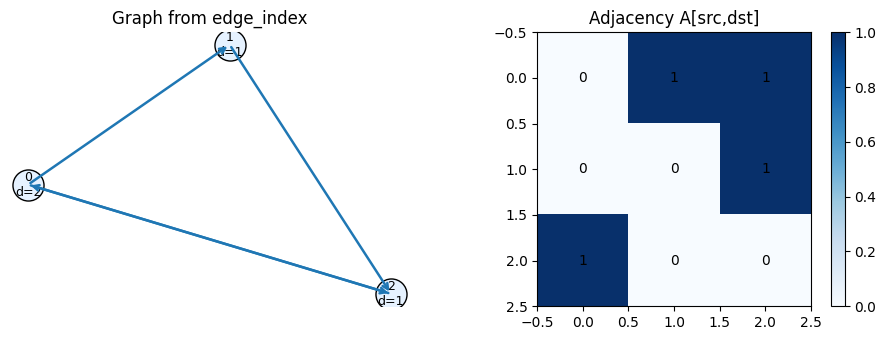

In [8]:
edge_index_demo = torch.tensor([[0, 0, 1, 2], [1, 2, 2, 0]])
A_demo = edge_index_to_adj(edge_index_demo, 3)
deg_demo = degree_from_edge_index(edge_index_demo, 3)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
pos = {0:(0.1,0.5), 1:(0.5,0.82), 2:(0.82,0.25)}
for n, (x0, y0) in pos.items():
    ax[0].scatter([x0], [y0], s=500, c='#e6f2ff', edgecolors='black', zorder=3)
    label = str(n) + "\nd=" + str(int(deg_demo[n].item()))
    ax[0].text(x0, y0, label, ha='center', va='center', fontsize=9)
for s, d in edge_index_demo.t().tolist():
    ax[0].annotate('', xy=pos[d], xytext=pos[s], arrowprops=dict(arrowstyle='->', lw=1.8, color='#1f77b4'))
ax[0].set_title('Graph from edge_index')
ax[0].axis('off')

im = ax[1].imshow(A_demo.detach().cpu().numpy(), cmap='Blues', vmin=0, vmax=1)
ax[1].set_title('Adjacency A[src,dst]')
for i in range(3):
    for j in range(3):
        ax[1].text(j, i, int(A_demo[i,j].item()), ha='center', va='center')
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## <span style="color:Orange">Problem 2</span>: One Message-Passing Step

A message-passing layer updates each node by combining its own features with aggregated neighbor information.

Here, neighbors are incoming (`j -> i`). Implement mean aggregation over incoming messages, then combine with a self-term.

Goal: correctly gather by destination and normalize by incoming count.


In [28]:
def message_passing_step(x, edge_index, w_self, w_msg):
    N = x.size(0)
    src, dst = edge_index
    # YOUR CODE HERE
    # I used AI to explain the message passing process and that the self messages combine with the neighbor messages and stuff. It gave me the equation I should use
    message = x[src] @ w_msg
    talking_to_myself = x @ w_self
    incoming = torch.zeros((N, message.size(1)))
    for i in range(len(dst)):
      incoming[dst[i]] += message[i]

    adjacent = edge_index_to_adj(edge_index, N)
    degree = torch.sum(adjacent, axis=0).clamp(min=1)
    mean_messages = incoming / degree.unsqueeze(1)

    return talking_to_myself + mean_messages


    raise NotImplementedError('Implement message_passing_step')

x = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
edge_index = torch.tensor([[0, 2, 1], [1, 1, 2]])
out = message_passing_step(x, edge_index, torch.eye(2), torch.eye(2))
assert torch.allclose(out[1], torch.tensor([1.0, 1.5]), atol=1e-6)
print('Problem 2 checks passed.')

Problem 2 checks passed.


### <span style="color:LightGreen"> Figure for Problem 2</span>

Why this plot:
- Left: highlights which edges contribute to a target node's aggregation
- Right: compares one feature before and after the update

This makes the effect of one message-passing step observable on concrete data.


In [ ]:
x_demo = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
edge_demo = torch.tensor([[0, 2, 1], [1, 1, 2]])
out_demo = message_passing_step(x_demo, edge_demo, torch.eye(2), torch.eye(2))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
pos = {0:(0.15,0.6), 1:(0.55,0.78), 2:(0.84,0.35)}
for n, (x0, y0) in pos.items():
    ax[0].scatter([x0], [y0], s=600, c='#f2f8ff', edgecolors='black')
    ax[0].text(x0, y0, 'n'+str(n), ha='center', va='center')
for s,d in edge_demo.t().tolist():
    color = '#d62728' if d == 1 else '#7f7f7f'
    lw = 2.3 if d == 1 else 1.4
    ax[0].annotate('', xy=pos[d], xytext=pos[s], arrowprops=dict(arrowstyle='->', lw=lw, color=color))
ax[0].set_title('Incoming edges highlighted for node 1')
ax[0].axis('off')

idx = np.arange(3)
ax[1].bar(idx-0.15, x_demo[:,0].numpy(), width=0.3, label='input f0')
ax[1].bar(idx+0.15, out_demo[:,0].detach().numpy(), width=0.3, label='updated f0')
ax[1].set_xticks(idx)
ax[1].set_xticklabels(['node 0', 'node 1', 'node 2'])
ax[1].legend(frameon=False)
ax[1].set_title('One step update effect')
plt.tight_layout(); plt.show()

## <span style="color:Orange">Problem 3</span>: Permutation-Invariant Graph Readout

Graph-level outputs should not change if node rows are permuted. A correct readout must be permutation invariant.

- `x` is a (num_nodes, num_features) tensor of node features, potentially from multiple graphs
- `batch` is a (num_nodes,) tensor where `batch[i]` indicates which graph node i belongs to
- The output should be a `(num_graphs, num_features)` tensor with one row per graph. For example, if `batch = [0, 0, 1, 1]` then nodes 0 and 1 belong to graph 0 and nodes 2 and 3 belong to graph 1, and the output should have shape `(2, num_features)`.

Implement `global_mean_pool(x, batch)` to produce one embedding per graph.


In [ ]:
def global_mean_pool(x, batch):
    # YOUR CODE HERE
    raise NotImplementedError('Implement global_mean_pool')

x = torch.tensor([[1., 2.], [3., 4.], [10., 0.], [14., 2.]])
b = torch.tensor([0, 0, 1, 1])
g = global_mean_pool(x, b)
perm = torch.tensor([1, 0, 3, 2])
assert torch.allclose(g, global_mean_pool(x[perm], b[perm]))
print('Problem 3 checks passed.')

### <span style="color:LightGreen"> Figure for Problem 3</span>

Why this plot:
- Left: original node-feature matrix (order-dependent representation)
- Right: pooled graph summaries before/after permutation

You should see matching graph summaries, demonstrating invariance.


In [ ]:
x_demo = torch.tensor([[1., 2.], [3., 4.], [10., 0.], [14., 2.]])
b_demo = torch.tensor([0, 0, 1, 1])
perm = torch.tensor([1, 0, 3, 2])
g0 = global_mean_pool(x_demo, b_demo)
g1 = global_mean_pool(x_demo[perm], b_demo[perm])

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].imshow(x_demo.numpy(), cmap='viridis', aspect='auto')
ax[0].set_title('Original node feature matrix')

w = 0.35
idx = np.arange(g0.size(0))
ax[1].bar(idx-w/2, g0[:,0].detach().numpy(), width=w, label='original')
ax[1].bar(idx+w/2, g1[:,0].detach().numpy(), width=w, label='permuted')
ax[1].set_xticks(idx)
ax[1].set_xticklabels(['graph 0', 'graph 1'])
ax[1].set_title('Graph means match')
ax[1].legend(frameon=False)
plt.tight_layout(); plt.show()

## <span style="color:Orange">Problem 4</span>: Train a Tiny GNN for Graph Classification

This problem combines earlier components into a minimal training pipeline.

The forward pass should apply two message passing layers, each followed by a ReLU activation. Since each forward call processes a single graph, create the batch tensor as `torch.zeros(N, dtype=torch.long, device=x.device)` before pooling. Finally, pass the result through the output layer for classification.   

Synthetic rule:
- each graph has random directed edges
- label is `1` when `E > N`, else `0`

Complete forward and training logic so the model learns this relationship from data.


In [ ]:
def make_graph(num_nodes=8, feat_dim=4, p=0.2):
    x = torch.randn(num_nodes, feat_dim)
    edges = []
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j and random.random() < p:
                edges.append((i, j))
    if len(edges) == 0:
        edges = [(0, 1)]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    y = torch.tensor([1 if edge_index.size(1) > num_nodes else 0], dtype=torch.long)
    return x, edge_index, y

class TinyGNN(nn.Module):
    def __init__(self, in_dim=4, hid_dim=16, out_dim=2):
        super().__init__()
        self.w1_self = nn.Parameter(torch.randn(in_dim, hid_dim) * 0.1)
        self.w1_msg = nn.Parameter(torch.randn(in_dim, hid_dim) * 0.1)
        self.w2_self = nn.Parameter(torch.randn(hid_dim, hid_dim) * 0.1)
        self.w2_msg = nn.Parameter(torch.randn(hid_dim, hid_dim) * 0.1)
        self.head = nn.Linear(hid_dim, out_dim)

    def forward(self, x, edge_index):
        # YOUR CODE HERE
        raise NotImplementedError('Implement TinyGNN.forward')

model = TinyGNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
train_data = [make_graph(num_nodes=8, feat_dim=4, p=random.uniform(0.1, 0.35)) for _ in range(240)]
test_data = [make_graph(num_nodes=8, feat_dim=4, p=random.uniform(0.1, 0.35)) for _ in range(80)]

for epoch in range(35):
    # YOUR CODE HERE
    pass

@torch.no_grad()
def evaluate(model, data):
    model.eval()
    correct = 0
    for x, edge_index, y in data:
        x, edge_index, y = x.to(device), edge_index.to(device), y.to(device)
        pred = model(x, edge_index).argmax(dim=-1)
        correct += int((pred == y).item())
    return correct / len(data)

acc = evaluate(model, test_data)
print('Test accuracy: {:.3f}'.format(acc))
assert acc >= 0.75
print('Problem 4 checks passed.')

### <span style="color:LightGreen"> Figure for Problem 4</span>

Why this plot:
- Left: visualizes the synthetic label boundary in terms of edge count
- Right: shows model predictions on test graphs against edge count

This gives a diagnostic view of whether the learned decision aligns with the data-generating rule.


In [ ]:
N = 8
p = np.linspace(0.0, 0.5, 200)
expected_E = N * (N - 1) * p

edge_counts, labels, preds = [], [], []
with torch.no_grad():
    for x, edge_index, y in test_data:
        pred = model(x.to(device), edge_index.to(device)).argmax(dim=-1).item()
        edge_counts.append(edge_index.size(1))
        labels.append(int(y.item()))
        preds.append(pred)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(p, expected_E, lw=2.0)
ax[0].axhline(N, color='crimson', ls='--', lw=2)
ax[0].set_title('Setup: boundary at E = N')
ax[0].set_xlabel('edge probability p')
ax[0].set_ylabel('edge count')

correct = np.array(labels) == np.array(preds)
ax[1].scatter(edge_counts, preds, c=np.where(correct, '#2ca02c', '#d62728'), alpha=0.8)
ax[1].axvline(N, color='black', ls='--')
ax[1].set_yticks([0, 1])
ax[1].set_title('Test predictions')
ax[1].set_xlabel('edge count E')
ax[1].set_ylabel('predicted label')
plt.tight_layout(); plt.show()

## <span style="color:Orange">Problem 5</span>: Edge Model for Interaction Network

Some GNN formulations compute explicit edge messages before node updates.

Implement:
- `compute_edge_messages` to produce an edge feature for each `(src, dst)` by concatenating the source and destination feature vectors for each edge to form a `(num_edges, 2 * node_dim)` input and passing through the defined model.
- `aggregate_incoming` to sum incoming edge features per destination node. Note that this follows the same destination-wise accumulation pattern as problem 2, but summing edge feature vectors rather than node features. No mean normalization is needed here.

Goal: practice edge-centric computation and destination-wise accumulation.


In [ ]:
class EdgeModel(nn.Module):
    def __init__(self, node_dim=3, edge_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * node_dim, 16),
            nn.ReLU(),
            nn.Linear(16, edge_dim)
        )

    def compute_edge_messages(self, x, edge_index):
        # YOUR CODE HERE
        raise NotImplementedError('Implement compute_edge_messages')

    def aggregate_incoming(self, edge_feat, edge_index, num_nodes):
        # YOUR CODE HERE
        raise NotImplementedError('Implement aggregate_incoming')

N, D = 4, 3
x = torch.randn(N, D)
edge_index = torch.tensor([[0, 1, 3, 2], [1, 2, 1, 1]])
model_e = EdgeModel(node_dim=3, edge_dim=5)
edge_feat = model_e.compute_edge_messages(x, edge_index)
agg = model_e.aggregate_incoming(edge_feat, edge_index, N)
assert edge_feat.shape == (edge_index.size(1), 5)
assert agg.shape == (N, 5)
assert (agg[1].abs().sum() > 0).item()
print('Problem 5 checks passed.')

### <span style="color:LightGreen"> Figure for Problem 5</span>

Why this plot:
- Left: magnitude of each edge message
- Right: magnitude after aggregating incoming messages at each node

This helps verify that edge-level outputs are being accumulated by destination node as intended.


In [ ]:
N, D = 5, 3
x_demo = torch.randn(N, D)
edge_demo = torch.tensor([[0, 1, 4, 2, 3], [1, 2, 1, 1, 4]])
model_demo = EdgeModel(node_dim=3, edge_dim=5)
edge_feat_demo = model_demo.compute_edge_messages(x_demo, edge_demo)
agg_demo = model_demo.aggregate_incoming(edge_feat_demo, edge_demo, N)

edge_mag = edge_feat_demo.norm(dim=1).detach().cpu().numpy()
node_mag = agg_demo.norm(dim=1).detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].bar(np.arange(len(edge_mag)), edge_mag, color='#1f77b4')
ax[0].set_title('Per-edge message norm')
ax[0].set_xlabel('edge id')
ax[0].set_ylabel('norm')

ax[1].bar(np.arange(len(node_mag)), node_mag, color='#ff7f0e')
ax[1].set_title('Incoming aggregated norm per node')
ax[1].set_xlabel('node id')
ax[1].set_ylabel('norm')

plt.tight_layout(); plt.show()

## <span style="color:Orange">Acknowledgments</span>

* Initial version: Mark Neubauer

© Copyright 2026